# NB03 - simulación de speckle óptico 2D con PINN-SIREN modal
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | Maestría en Ciencias de la Computación — UJAT

---

Este notebook es una **copia didáctica y reproducible** del estado validado de NB03. No sustituye ni modifica el notebook original, NB01, NB02, los scripts experimentales ni los resultados existentes.

## Objetivo

Comprender cómo una PINN-SIREN resuelve la ecuación de Helmholtz 2D normalizada para propagar un campo óptico aleatorio desde $\tilde z=0$ hasta $\tilde z=1$, y cómo esa propagación produce un patrón de speckle.

La formulación validada trabaja en el plano cartesiano $(\tilde x,\tilde z)$:

$$\boxed{\frac{\partial^2E}{\partial\tilde x^2}+\frac{\partial^2E}{\partial\tilde z^2}+\tilde k^2E=0},\qquad \tilde k=2\pi.$$

| Coordenada | Interpretación |
|---|---|
| $\tilde x=x/\lambda$ | Dirección transversal |
| $\tilde z=z/\lambda$ | Dirección de propagación |
| $\tilde x\in[-10,10]$ | Ventana transversal de $20\lambda$ |
| $\tilde z\in[0,1]$ | Propagación validada hasta $1\lambda$ |

> **Alcance:** es una simulación escalar 2D en el plano $(x,z)$. En el plano final $z=1\lambda$ se obtiene un perfil transversal $I(x)$. Una imagen completa de cámara $I(x,y)$ requeriría extender el campo a dos coordenadas transversales y una de propagación.

## 0. Imports y rutas reproducibles

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

# Funciona al ejecutar desde la raíz del proyecto o desde notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / 'scripts' / 'experiments'
REFERENCE_JSON = RESULTS_DIR / 'nb03_angular_spectrum_reference_z1_corr0.10.json'
REFERENCE_NPZ = RESULTS_DIR / 'nb03_angular_spectrum_reference_z1_corr0.10.npz'
SUMMARY_JSON = RESULTS_DIR / 'nb03_modal_multiseed_z1_omega1_summary.json'
MODAL_SCRIPT = SCRIPTS_DIR / 'nb03_modal_pinn_siren.py'

required = [REFERENCE_JSON, REFERENCE_NPZ, SUMMARY_JSON, MODAL_SCRIPT]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos requeridos:\n' + '\n'.join(map(str, missing)))

print(f'Raíz del proyecto : {PROJECT_ROOT}')
print('Archivos validados localizados correctamente.')

Raíz del proyecto : C:\roberto\Tesis_Maestria
Archivos validados localizados correctamente.


---
## 1. De la ecuación física a la ecuación normalizada

En un medio homogéneo, sin fuentes y usando un fasor monocromático, la ecuación escalar de Helmholtz en el plano $(x,z)$ es

$$\frac{\partial^2E}{\partial x_{\mathrm{físico}}^2}+\frac{\partial^2E}{\partial z_{\mathrm{físico}}^2}+k_{\mathrm{real}}^2E=0,$$

con

$$k_{\mathrm{real}}=\frac{2\pi}{\lambda}.$$

Definimos

$$\tilde x=\frac{x_{\mathrm{físico}}}{\lambda},\qquad \tilde z=\frac{z_{\mathrm{físico}}}{\lambda}.$$

Por la regla de la cadena,

$$\frac{\partial^2E}{\partial x_{\mathrm{físico}}^2}=\frac{1}{\lambda^2}\frac{\partial^2E}{\partial\tilde x^2},\qquad \frac{\partial^2E}{\partial z_{\mathrm{físico}}^2}=\frac{1}{\lambda^2}\frac{\partial^2E}{\partial\tilde z^2}.$$

Al sustituir y multiplicar por $\lambda^2$:

$$\boxed{\frac{\partial^2E}{\partial\tilde x^2}+\frac{\partial^2E}{\partial\tilde z^2}+\tilde k^2E=0},\qquad \tilde k=k_{\mathrm{real}}\lambda=2\pi.$$

> **Nota para el código:** las variables llamadas x, z y K representan $\tilde x$, $\tilde z$ y $\tilde k$. La longitud de onda de 638 nm permite convertir nuevamente a unidades físicas, pero no entra como un número diminuto durante el entrenamiento.

In [2]:
with REFERENCE_JSON.open(encoding='utf-8') as file:
    reference_report = json.load(file)

lambda_laser = reference_report['lambda_laser_m']
k_tilde = 2 * np.pi
coordinates = reference_report['coordinates']

print('Configuración física validada:')
print(f'  λ                         : {lambda_laser*1e9:.0f} nm')
print(f'  k̃                         : 2π = {k_tilde:.6f}')
print(f'  x̃                         : {coordinates["x_interval_lambda"]}')
print(f'  z̃                         : {coordinates["z_interval_lambda"]}')
print(f'  Ancho físico              : {coordinates["width_lambda"]*lambda_laser*1e6:.3f} μm')
print(f'  Distancia física validada : {coordinates["distance_lambda"]*lambda_laser*1e6:.3f} μm')

Configuración física validada:
  λ                         : 638 nm
  k̃                         : 2π = 6.283185
  x̃                         : [-10.0, 10.0]
  z̃                         : [0.0, 1.0]
  Ancho físico              : 12.760 μm
  Distancia física validada : 0.638 μm


---
## 2. Dato óptico inicial: pantalla de fase aleatoria

En NB02 la frontera provenía de una onda plana analítica. En NB03 el dato conocido es un campo inicial aleatorio en $\tilde z=0$:

$$E(\tilde x,0)=e^{i\phi(\tilde x)}.$$

La fase $\phi(\tilde x)$ se genera como un proceso gaussiano de media cero, desviación estándar de 2 rad y longitud de correlación $0.1\lambda$. La correlación evita una pantalla completamente independiente píxel a píxel y define su escala espacial.

Por Euler,

$$E_{\mathrm{real}}(\tilde x,0)=\cos\phi(\tilde x),\qquad E_{\mathrm{imag}}(\tilde x,0)=\sin\phi(\tilde x).$$

Antes de propagar se proyecta el campo sobre los modos físicamente propagantes. Por eso el campo radiativo utilizado por la PINN puede tener potencia media menor que uno, aunque $|e^{i\phi}|=1$ antes de la proyección.

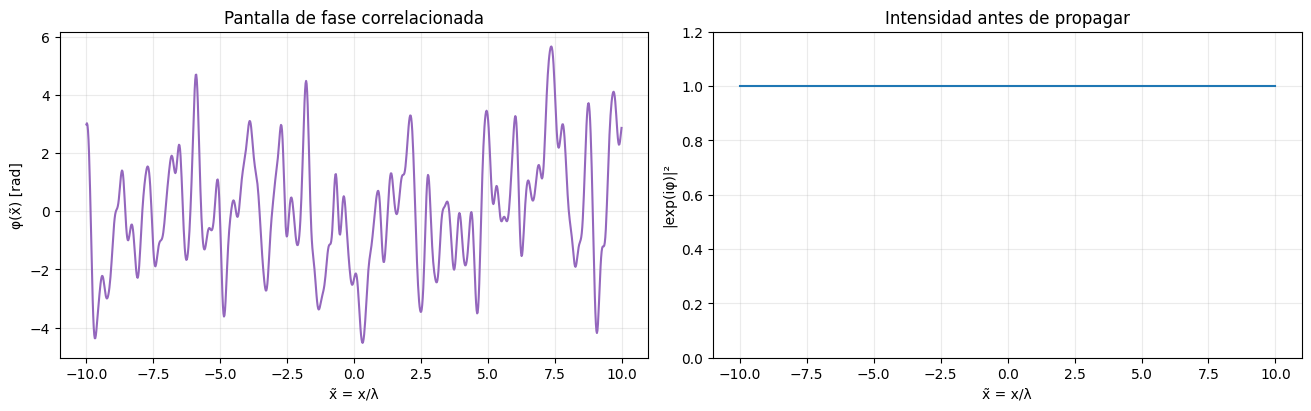

Muestras transversales : 1024
Intervalo x̃           : [-10.0, 10.0]
Figura guardada        : C:\roberto\Tesis_Maestria\results\figures\nb03_nuevo_pantalla_inicial.png


In [3]:
reference = dict(np.load(REFERENCE_NPZ))
x_tilde = reference['x_lambda']
phase = reference['phase']
field_reference_all_z = reference['field_all_z']

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(x_tilde, phase, color='tab:purple')
axes[0].set_title('Pantalla de fase correlacionada')
axes[0].set_xlabel('x̃ = x/λ')
axes[0].set_ylabel('φ(x̃) [rad]')
axes[0].grid(alpha=0.25)

axes[1].plot(x_tilde, np.abs(np.exp(1j*phase))**2, color='tab:blue')
axes[1].set_title('Intensidad antes de propagar')
axes[1].set_xlabel('x̃ = x/λ')
axes[1].set_ylabel('|exp(iφ)|²')
axes[1].set_ylim(0, 1.2)
axes[1].grid(alpha=0.25)
figure_path = FIGURES_DIR / 'nb03_nuevo_pantalla_inicial.png'
fig.savefig(figure_path, dpi=170, bbox_inches='tight')
plt.show()

print(f'Muestras transversales : {len(x_tilde)}')
print(f'Intervalo x̃           : [{x_tilde.min():.1f}, {x_tilde.max():.1f}]')
print(f'Figura guardada        : {figure_path}')

---
## 3. Espectro angular y dirección de propagación

El campo inicial se descompone en ondas planas transversales:

$$E(\tilde x,0)=\sum_m a_m(0)e^{i\tilde k_{x,m}\tilde x}.$$

Para cada modo, Helmholtz exige

$$\tilde k_{x,m}^2+\tilde k_{z,m}^2=\tilde k^2.$$

De aquí,

$$\tilde k_{z,m}=\sqrt{\tilde k^2-\tilde k_{x,m}^2}.$$

Si $|\tilde k_{x,m}|\leq\tilde k$, entonces $\tilde k_{z,m}$ es real y el modo se propaga. Si $|\tilde k_{x,m}|>\tilde k$, es evanescente.

Para seleccionar ondas que avanzan hacia $+z$ con la convención temporal $e^{-i\omega t}$ se usa

$$a_m(\tilde z)=a_m(0)e^{i\tilde k_{z,m}\tilde z},$$

y, por tanto,

$$\boxed{a_m'(0)=i\tilde k_{z,m}a_m(0)}.$$

Esta derivada inicial no es una etiqueta tomada del plano final: se obtiene de la condición física de onda saliente.

Discretización espectral:
  Modos espectrales totales : 1024
  Modos propagantes         : 41
  Fracción de energía       : 0.4099
  Realizaciones estadísticas: 64


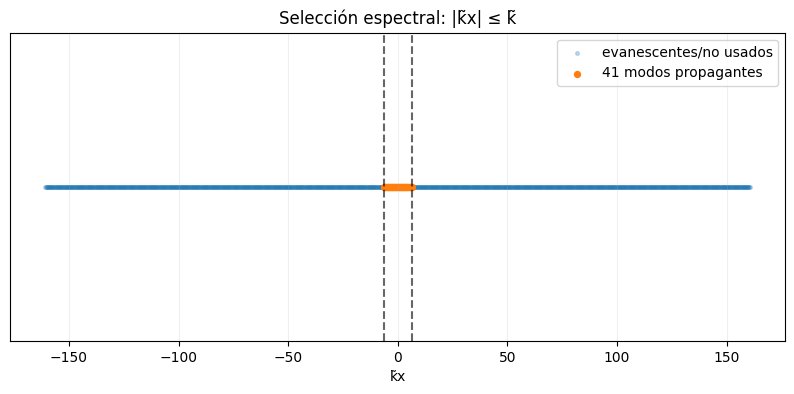

Figura guardada: C:\roberto\Tesis_Maestria\results\figures\nb03_nuevo_modos_propagantes.png


In [4]:
physics = reference_report['physics']
sampling = reference_report['sampling']
propagating_mask = reference['propagating_mask'].astype(bool)
kx_all = reference['kx']

print('Discretización espectral:')
print(f'  Modos espectrales totales : {physics["total_spectral_modes"]}')
print(f'  Modos propagantes         : {physics["propagating_modes"]}')
print(f'  Fracción de energía       : {physics["propagating_energy_fraction"]:.4f}')
print(f'  Realizaciones estadísticas: {sampling["n_realizations"]}')

plt.figure(figsize=(10, 4))
plt.scatter(kx_all[~propagating_mask], np.zeros((~propagating_mask).sum()),
            s=7, alpha=0.25, label='evanescentes/no usados')
plt.scatter(kx_all[propagating_mask], np.zeros(propagating_mask.sum()),
            s=18, label='41 modos propagantes')
plt.axvline(-k_tilde, color='black', linestyle='--', alpha=0.6)
plt.axvline(k_tilde, color='black', linestyle='--', alpha=0.6)
plt.xlabel('k̃x')
plt.yticks([])
plt.title('Selección espectral: |k̃x| ≤ k̃')
plt.legend()
plt.grid(axis='x', alpha=0.2)
figure_path = FIGURES_DIR / 'nb03_nuevo_modos_propagantes.png'
plt.savefig(figure_path, dpi=170, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {figure_path}')

### Visualización física de la propagación de referencia

El siguiente mapa muestra cómo cambia la intensidad del espectro angular desde la pantalla inicial hasta $\tilde z=1$. Las franjas irregulares aparecen por la interferencia entre los modos propagantes. El mapa sirve como referencia física; la comparación cuantitativa con la PINN se presenta después.

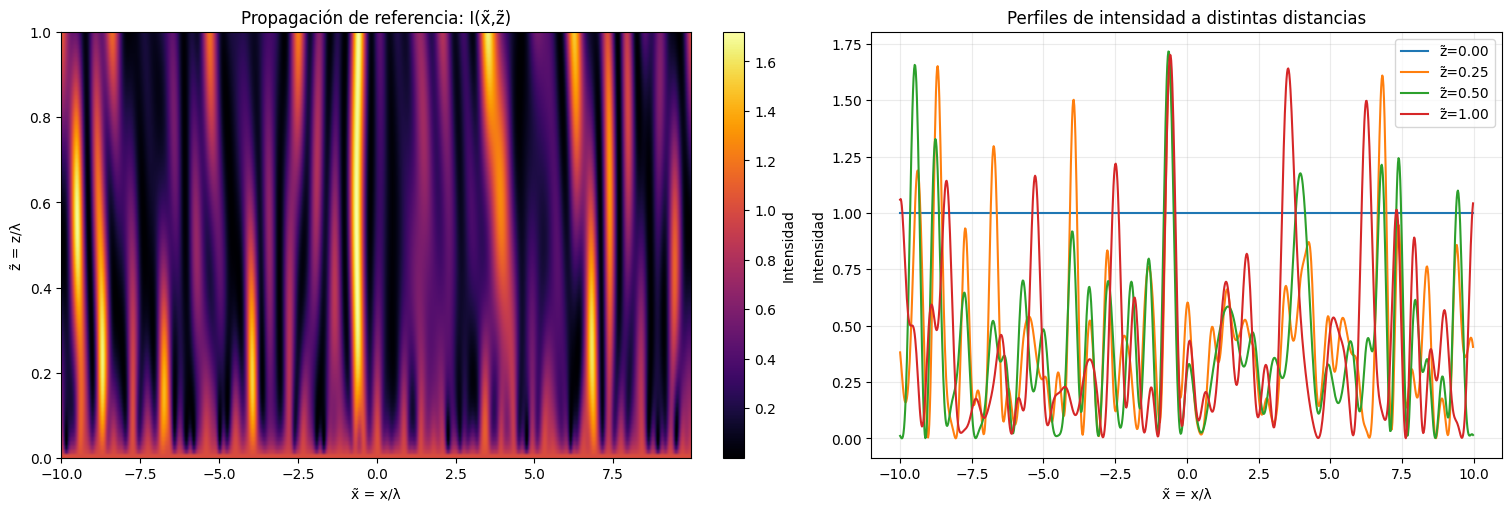

Figura guardada: C:\roberto\Tesis_Maestria\results\figures\nb03_nuevo_propagacion_referencia_xz.png


In [5]:
z_reference = reference['z_lambda']
intensity_reference_xz = np.abs(field_reference_all_z)**2

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
image = axes[0].imshow(
    intensity_reference_xz,
    origin='lower', aspect='auto', cmap='inferno',
    extent=[x_tilde.min(), x_tilde.max(), z_reference.min(), z_reference.max()]
)
axes[0].set_title('Propagación de referencia: I(x̃,z̃)')
axes[0].set_xlabel('x̃ = x/λ')
axes[0].set_ylabel('z̃ = z/λ')
fig.colorbar(image, ax=axes[0], label='Intensidad')

selected = sorted(set([0, len(z_reference)//4, len(z_reference)//2, len(z_reference)-1]))
for index in selected:
    axes[1].plot(x_tilde, intensity_reference_xz[index],
                 label=f'z̃={z_reference[index]:.2f}')
axes[1].set_title('Perfiles de intensidad a distintas distancias')
axes[1].set_xlabel('x̃ = x/λ')
axes[1].set_ylabel('Intensidad')
axes[1].grid(alpha=0.25)
axes[1].legend()

figure_path = FIGURES_DIR / 'nb03_nuevo_propagacion_referencia_xz.png'
fig.savefig(figure_path, dpi=170, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {figure_path}')

---
## 4. Reducción modal de Helmholtz 2D

Escribimos el campo como

$$E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x}.$$

Sus derivadas son

$$\frac{\partial^2E}{\partial\tilde x^2}=\sum_m-\tilde k_{x,m}^2a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x},$$

$$\frac{\partial^2E}{\partial\tilde z^2}=\sum_m a_m''(\tilde z)e^{i\tilde k_{x,m}\tilde x}.$$

Al sustituir en Helmholtz y agrupar cada modo independiente:

$$\boxed{a_m''(\tilde z)+(\tilde k^2-\tilde k_{x,m}^2)a_m(\tilde z)=0}.$$

Como $\tilde k_{z,m}^2=\tilde k^2-\tilde k_{x,m}^2$, también puede escribirse

$$\boxed{a_m''(\tilde z)+\tilde k_{z,m}^2a_m(\tilde z)=0}.$$

> La descomposición modal no elimina la física de Helmholtz: aprovecha la periodicidad transversal para expresar exactamente la misma ecuación 2D como un sistema de ecuaciones para los coeficientes.

## 5. ¿Cuáles son los datos de entrenamiento?

| Información | Cantidad | Uso |
|---|---:|---|
| Pantalla inicial $E(\tilde x,0)$ | 1,024 muestras | Construir el espectro inicial |
| Coeficientes $a_m(0)$ | 41 complejos | Condición inicial del campo |
| Derivadas $a_m'(0)$ | 41 complejas | Seleccionar propagación hacia $+z$ |
| Puntos $\tilde z_j$ | 256 aleatorios por época | Evaluar el residuo físico |
| Valores exactos interiores | 0 | No se usan para entrenar |
| Campo por espectro angular en $\tilde z=1$ | 1,024 complejos | Solo validación final |

Por lo tanto, NB03 no aprende copiando campos propagados. Aprende con las condiciones iniciales y con la ecuación diferencial.

---
## 6. Condición de Cauchy dura

Para cada modo, la salida se construye como

$$\boxed{a_{m,\theta}(\tilde z)=a_m(0)+\tilde z\,a_m'(0)+\tilde z^2N_{m,\theta}(\tilde z)}.$$

En $\tilde z=0$:

$$a_{m,\theta}(0)=a_m(0).$$

Al derivar,

$$a_{m,\theta}'(\tilde z)=a_m'(0)+2\tilde zN_{m,\theta}(\tilde z)+\tilde z^2N_{m,\theta}'(\tilde z),$$

y al evaluar en cero:

$$a_{m,\theta}'(0)=a_m'(0).$$

Las dos condiciones se satisfacen exactamente para cualquier valor de los pesos de la red. La PINN solo tiene que aprender la corrección compatible con Helmholtz.

In [6]:
# Fragmento de la implementación real, mostrado sin modificar el script.
script_lines = MODAL_SCRIPT.read_text(encoding='utf-8').splitlines()
start = next(i for i, line in enumerate(script_lines) if line.startswith('class ModalSiren'))
end = next(i for i, line in enumerate(script_lines[start:], start=start)
           if line.startswith('def modal_residual'))
print('\n'.join(script_lines[start:end]))

class ModalSiren(nn.Module):
    def __init__(self, coefficient0, derivative0, correction_scale, distance):
        super().__init__()
        self.distance = float(distance)
        n_outputs = int(coefficient0.numel())
        layers = [SineLayer(1, HIDDEN_DIM, FIRST_OMEGA, first=True)]
        for _ in range(NUM_LAYERS - 1):
            layers.append(SineLayer(
                HIDDEN_DIM, HIDDEN_DIM, HIDDEN_OMEGA
            ))
        final = nn.Linear(HIDDEN_DIM, n_outputs)
        # Comenzar desde la prolongacion lineal impuesta por Cauchy. Una
        # salida aleatoria comun a todos los modos introduce energia espuria
        # en los coeficientes debiles antes del primer paso de optimizacion.
        nn.init.zeros_(final.weight)
        nn.init.zeros_(final.bias)
        layers.append(final)
        self.net = nn.Sequential(*layers)
        self.register_buffer("coefficient0", coefficient0.reshape(1, -1))
        self.register_buffer("derivative0", derivative0.reshape(1, -1))


---
## 7. Arquitectura PINN-SIREN modal

La red recibe una coordenada de propagación y devuelve las partes real e imaginaria de todos los modos:

$$\tilde z\longrightarrow\operatorname{SIREN}_\theta\longrightarrow\{\operatorname{Re}a_m,\operatorname{Im}a_m\}_{m=1}^{41}.$$

| Elemento | Configuración validada |
|---|---:|
| Entrada | 1 valor: $\tilde z$ |
| Capas ocultas | 4 |
| Neuronas por capa | 128 |
| Frecuencia primera capa | $\omega_0=1$ |
| Frecuencia interna | $1$ |
| Salidas reales | $2\times41=82$ |
| Inicialización de la salida | Cero |

La salida final se inicializa en cero para comenzar exactamente desde la prolongación de Cauchy $a_m(0)+\tilde z a_m'(0)$ y evitar energía espuria inicial en modos débiles.

---
### Calibración de $\omega_0$: la regla de NB01 aplicada aquí

La primera versión de esta arquitectura usaba $\omega_0=30$, el valor que
Sitzmann et al. (2020) recomienda para señales de imagen. NB01 estableció
que $\omega_0$ debe calibrarse al contenido frecuencial de la solución sobre el
dominio de entrada de la red, con la regla $\omega_0pprox k/2\pi$.

Aquí la red recibe $	ilde z$ normalizado y cada coeficiente modal oscila como
$a_m(	ilde z)\propto e^{i k_{z,m}	ilde z}$ con $k_{z,m}\le k=2\pi$: **como
máximo una oscilación completa en todo el dominio**. El valor que la regla
predice es $\omega_0=1$, no 30.

Barrido sobre la pantalla 42, 5,000 épocas idénticas, sin refinamiento:

| $\omega_0$ | $L^2$ total | $L^2$ propagante | Residuo de la EDO |
|---:|---:|---:|---:|
| **1** | 3.819 % | **0.090 %** | $3.59	imes10^{-3}$ |
| 5 | 3.819 % | 0.081 % | $2.61	imes10^{-3}$ |
| 15 | 3.833 % | 0.329 % | $1.33	imes10^{-2}$ |
| 30 | 4.962 % | 3.172 % | $5.49	imes10^{-2}$ |

El error propagante degrada en un factor de 35 entre el valor calibrado y el
descalibrado. Consolidado sobre las cinco pantallas, el cambio de $\omega_0=30$
a $\omega_0=1$ mueve el error propagante medio a lo largo de la propagación de
2.983 % a 0.042 %, y el máximo de 4.791 % a 0.084 %.

Con $\omega_0$ calibrado el $L^2$ total coincide con el piso evanescente de la
referencia (3.819 % frente a 3.818 % en la pantalla 42): el error del modelo
deja de ser medible por encima del límite estructural de la representación, que
sólo contiene los 41 modos propagantes.

Este resultado es la razón por la que NB01 no es un preámbulo pedagógico: la
regla derivada allí es la que hace funcionar bien la formulación modal aquí.


## 8. Residuo físico y función de pérdida

Para cada modo y punto de colocación:

$$R_{m,\theta}(\tilde z_j)=a_{m,\theta}''(\tilde z_j)+\tilde k_{z,m}^2a_{m,\theta}(\tilde z_j).$$

La pérdida es esencialmente

$$\mathcal L_{\mathrm{física}}=\frac{1}{N_zN_m}\sum_{j=1}^{N_z}\sum_{m=1}^{N_m}\left|\frac{R_{m,\theta}(\tilde z_j)}{s_m}\right|^2,$$

donde $s_m$ es una escala asociada con la amplitud de cada modo. Esta normalización evita que los modos energéticamente fuertes dominen el entrenamiento.

No aparece una pérdida de frontera porque la condición de Cauchy es dura. Tampoco aparece una pérdida de datos interiores porque no se usan etiquetas en el interior.

In [7]:
with SUMMARY_JSON.open(encoding='utf-8') as file:
    summary = json.load(file)

protocol = summary['protocol']
print('Protocolo validado:')
for key, value in protocol.items():
    print(f'  {key:<24}: {value}')
print('\nLa referencia confirma que interior_labels = False.')

Protocolo validado:
  initial_epochs          : 5000
  finetune_epochs         : 3000
  initial_learning_rate   : 0.0002
  finetune_learning_rate  : 5e-05
  n_z_per_epoch           : 256
  n_propagating_modes     : 41
  interior_labels         : False

La referencia confirma que interior_labels = False.


---
## 9. Entrenamiento reproducible y protegido

La validación de cada pantalla utilizó una corrida inicial de 5,000 épocas con tasa $2\times10^{-4}$ y un refinamiento de 3,000 épocas con tasa $5\times10^{-5}$. En cada época se muestrean 256 posiciones de $\tilde z$.

La siguiente celda está desactivada por seguridad. Ejecutar el notebook completo solo carga y analiza resultados. Para entrenar una nueva réplica hay que cambiar explícitamente RUN_TRAINING a True; los sufijos nuevo evitan sobrescribir los modelos validados.

In [8]:
RUN_TRAINING = False

if RUN_TRAINING:
    common = os.environ.copy()
    common.update({
        'NB03_DISTANCE_LAMBDA': '1',
        'NB03_REFERENCE_SUFFIX': '_z1_corr0.10',
        'NB03_SEED': '42',
        'NB03_MODAL_N_Z_TRAIN': '256',
        'NB03_MODAL_HIDDEN_DIM': '128',
        'NB03_MODAL_NUM_LAYERS': '4',
        'NB03_MODAL_FIRST_OMEGA': '1',
        'NB03_MODAL_HIDDEN_OMEGA': '1',
    })

    initial_env = common.copy()
    initial_env.update({
        'NB03_MODAL_EPOCHS': '5000',
        'NB03_MODAL_LR': '2e-4',
        'NB03_MODAL_OUTPUT_SUFFIX': '_z1_nuevo_initial',
        'NB03_MODAL_RESUME_MODEL': '',
    })
    subprocess.run([sys.executable, str(MODAL_SCRIPT)], cwd=PROJECT_ROOT,
                   env=initial_env, check=True)

    initial_model = RESULTS_DIR / 'models' / 'nb03_modal_pinn_siren_z1_nuevo_initial.pt'
    finetune_env = common.copy()
    finetune_env.update({
        'NB03_MODAL_EPOCHS': '3000',
        'NB03_MODAL_LR': '5e-5',
        'NB03_MODAL_OUTPUT_SUFFIX': '_z1_nuevo_finetune',
        'NB03_MODAL_RESUME_MODEL': str(initial_model),
    })
    subprocess.run([sys.executable, str(MODAL_SCRIPT)], cwd=PROJECT_ROOT,
                   env=finetune_env, check=True)
else:
    print('Entrenamiento desactivado. Se usarán los resultados validados existentes.')

Entrenamiento desactivado. Se usarán los resultados validados existentes.


---
## 10. Referencia independiente y métricas

Después del entrenamiento se compara el campo de la PINN con el método del espectro angular en $\tilde z=1$.

### Error L2 complejo

$$\varepsilon_{L^2}=\frac{\|E_{\mathrm{PINN}}-E_{\mathrm{AS}}\|_2}{\|E_{\mathrm{AS}}\|_2}.$$

### Coherencia compleja

$$\gamma=\frac{|\langle E_{\mathrm{AS}},E_{\mathrm{PINN}}\rangle|}{\|E_{\mathrm{AS}}\|_2\|E_{\mathrm{PINN}}\|_2}.$$

### Intensidad y contraste

$$I=|E|^2,\qquad C=\frac{\sigma_I}{\langle I\rangle}.$$

Para una realización finita no se exige que $C$ sea exactamente uno. El criterio riguroso usado es comparar el contraste de la PINN con el contraste de su propia referencia:

$$\varepsilon_{L^2}<5\%,\qquad |C_{\mathrm{PINN}}-C_{\mathrm{AS}}|<0.05.$$

El espectro angular no proporciona etiquetas interiores durante el entrenamiento; se reserva para evaluar el resultado.

In [9]:
rows = summary['per_screen']
print('VALIDACIÓN EN CINCO PANTALLAS — z = 1λ')
print('-' * 104)
print(f'{"Semilla":>8} {"L2 complejo":>13} {"Coherencia":>12} '
      f'{"Corr. I":>10} {"C ref":>10} {"C PINN":>10} {"|ΔC|":>10} {"Acepta":>9}')
print('-' * 104)
for row in rows:
    print(f'{row["screen_seed"]:>8d} '
          f'{100*row["complex_l2_at_z1"]:>12.3f}% '
          f'{row["complex_coherence_at_z1"]:>12.6f} '
          f'{row["intensity_correlation_at_z1"]:>10.6f} '
          f'{row["contrast_reference"]:>10.4f} '
          f'{row["contrast_pinn"]:>10.4f} '
          f'{row["absolute_contrast_error"]:>10.4f} '
          f'{str(row["reference_fidelity_pass"]):>9}')

VALIDACIÓN EN CINCO PANTALLAS — z = 1λ
--------------------------------------------------------------------------------------------------------
 Semilla   L2 complejo   Coherencia    Corr. I      C ref     C PINN       |ΔC|    Acepta
--------------------------------------------------------------------------------------------------------
      42        3.819%     0.999271   0.998434     0.9063     0.9012     0.0051      True
     123        2.402%     0.999712   0.999346     0.8827     0.8821     0.0006      True
     321        3.573%     0.999362   0.998581     0.9200     0.9231     0.0030      True
     777        2.947%     0.999566   0.999605     1.2246     1.2403     0.0157      True
    2026        3.064%     0.999531   0.998441     0.7812     0.7841     0.0029      True


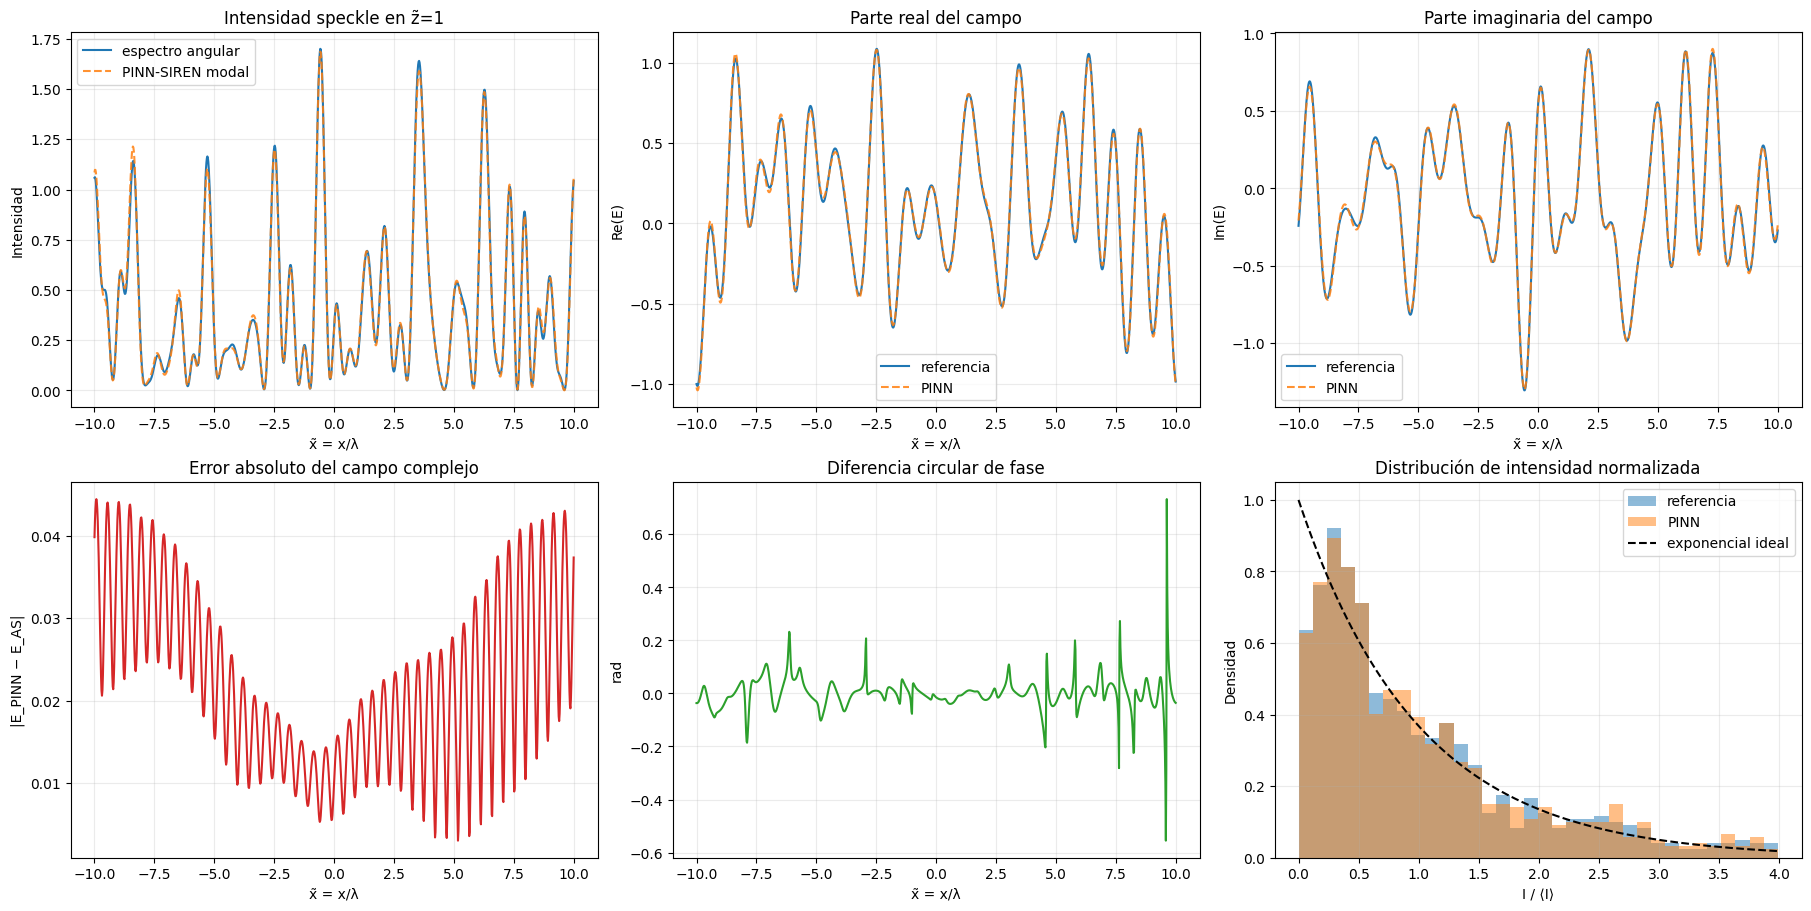

Figura guardada: C:\roberto\Tesis_Maestria\results\figures\nb03_nuevo_comparacion_z1.png


In [10]:
example_path = RESULTS_DIR / 'nb03_modal_pinn_siren_z1_screen42_omega1_finetune.npz'
example = dict(np.load(example_path))
x_example = example['x_lambda']
field_pred = example['field_pred']
field_ref = example['field_reference']

I_pred = np.abs(field_pred)**2
I_ref = np.abs(field_ref)**2
phase_error = np.angle(field_pred * np.conj(field_ref))

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes[0,0].plot(x_example, I_ref, label='espectro angular')
axes[0,0].plot(x_example, I_pred, '--', label='PINN-SIREN modal', alpha=0.85)
axes[0,0].set_title('Intensidad speckle en z̃=1')
axes[0,0].set_ylabel('Intensidad')
axes[0,0].legend()

axes[0,1].plot(x_example, field_ref.real, label='referencia')
axes[0,1].plot(x_example, field_pred.real, '--', label='PINN', alpha=0.85)
axes[0,1].set_title('Parte real del campo')
axes[0,1].set_ylabel('Re(E)')
axes[0,1].legend()

axes[0,2].plot(x_example, field_ref.imag, label='referencia')
axes[0,2].plot(x_example, field_pred.imag, '--', label='PINN', alpha=0.85)
axes[0,2].set_title('Parte imaginaria del campo')
axes[0,2].set_ylabel('Im(E)')
axes[0,2].legend()

axes[1,0].plot(x_example, np.abs(field_pred-field_ref), color='tab:red')
axes[1,0].set_title('Error absoluto del campo complejo')
axes[1,0].set_ylabel('|E_PINN − E_AS|')

axes[1,1].plot(x_example, phase_error, color='tab:green')
axes[1,1].set_title('Diferencia circular de fase')
axes[1,1].set_ylabel('rad')

normalized_ref = I_ref / I_ref.mean()
normalized_pred = I_pred / I_pred.mean()
bins = np.linspace(0, np.percentile(np.r_[normalized_ref, normalized_pred], 99.5), 35)
axes[1,2].hist(normalized_ref, bins=bins, density=True, alpha=0.50, label='referencia')
axes[1,2].hist(normalized_pred, bins=bins, density=True, alpha=0.50, label='PINN')
eta = np.linspace(0, bins[-1], 300)
axes[1,2].plot(eta, np.exp(-eta), 'k--', label='exponencial ideal')
axes[1,2].set_title('Distribución de intensidad normalizada')
axes[1,2].set_xlabel('I / ⟨I⟩')
axes[1,2].set_ylabel('Densidad')
axes[1,2].legend()

for axis in axes.ravel()[:5]:
    axis.set_xlabel('x̃ = x/λ')
    axis.grid(alpha=0.25)
axes[1,2].grid(alpha=0.25)
figure_path = FIGURES_DIR / 'nb03_nuevo_comparacion_z1.png'
fig.savefig(figure_path, dpi=170, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {figure_path}')

## 11. Resultados agregados

In [11]:
aggregate = summary['aggregate']
l2_stats = aggregate['complex_l2_at_z1']
coherence_stats = aggregate['complex_coherence_at_z1']
contrast_stats = aggregate['absolute_contrast_error']
residual_stats = aggregate['residual_normalized_rmse']
training_initial = np.array([row['training_seconds_initial'] for row in summary['per_screen']])
training_finetune = np.array([row['training_seconds_finetune'] for row in summary['per_screen']])
training_total = training_initial + training_finetune

print('RESUMEN AGREGADO')
print('=' * 62)
print(f'L2 complejo medio              : {100*l2_stats["mean"]:.3f}%')
print(f'L2 complejo mínimo–máximo      : {100*l2_stats["minimum"]:.3f}% – {100*l2_stats["maximum"]:.3f}%')
print(f'Coherencia compleja media      : {coherence_stats["mean"]:.6f}')
print(f'Error absoluto medio contraste : {contrast_stats["mean"]:.6f}')
print(f'Residuo modal RMSE medio       : {residual_stats["mean"]:.6f}')
print(f'Tiempo inicial medio           : {training_initial.mean():.1f} s')
print(f'Tiempo de ajuste fino medio    : {training_finetune.mean():.1f} s')
print(f'Tiempo total medio/pantalla    : {training_total.mean():.1f} s ({training_total.mean()/60:.2f} min)')
print(f'Pantallas aceptadas            : {aggregate["reference_fidelity_pass_count"]}/{aggregate["total_screens"]}')
print('\nResultado: la validación de fidelidad se cumple en las cinco pantallas.')

RESUMEN AGREGADO
L2 complejo medio              : 3.161%
L2 complejo mínimo–máximo      : 2.402% – 3.819%
Coherencia compleja media      : 0.999488
Error absoluto medio contraste : 0.005465
Residuo modal RMSE medio       : 0.002341
Tiempo inicial medio           : 219.0 s
Tiempo de ajuste fino medio    : 131.9 s
Tiempo total medio/pantalla    : 350.9 s (5.85 min)
Pantallas aceptadas            : 5/5

Resultado: la validación de fidelidad se cumple en las cinco pantallas.


### Error a lo largo de la distancia de propagación

Además del valor final en $\tilde z=1$, se conserva el error L2 complejo en los planos intermedios. Esto permite comprobar que el acuerdo no aparece únicamente en el extremo.

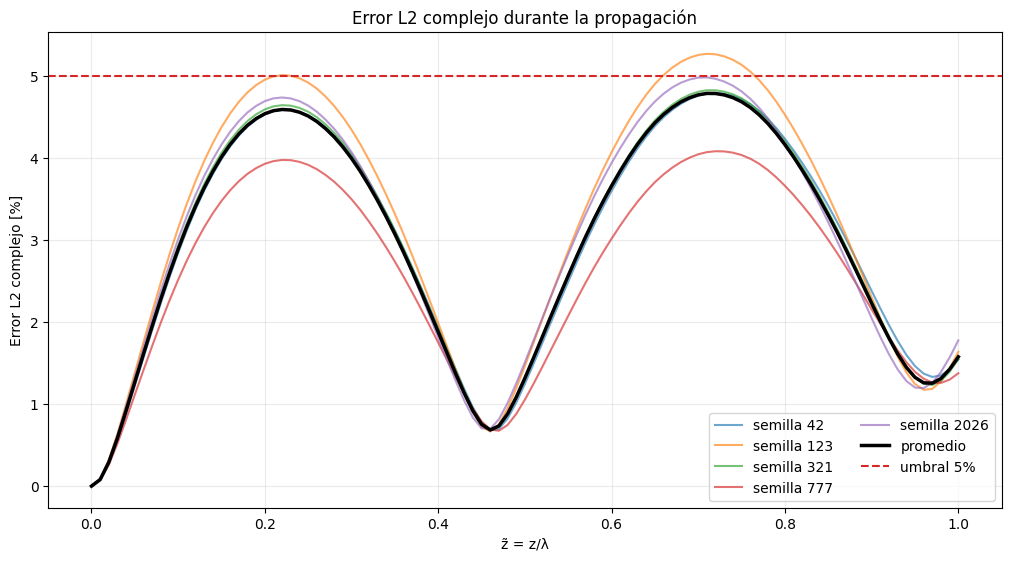

Figura guardada: C:\roberto\Tesis_Maestria\results\figures\nb03_nuevo_l2_durante_propagacion.png


In [12]:
curves_path = RESULTS_DIR / 'nb03_modal_multiseed_z1_l2_curves.npz'
curves = dict(np.load(curves_path))
z_curves = curves['z_lambda']
l2_curves = curves['l2_curves']
screen_seeds = curves['screen_seeds']

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for seed, curve in zip(screen_seeds, l2_curves):
    ax.plot(z_curves, 100*curve, alpha=0.65, label=f'semilla {int(seed)}')
ax.plot(z_curves, 100*l2_curves.mean(axis=0), color='black', linewidth=2.5,
        label='promedio')
ax.axhline(5, color='tab:red', linestyle='--', label='umbral 5%')
ax.set_title('Error L2 complejo durante la propagación')
ax.set_xlabel('z̃ = z/λ')
ax.set_ylabel('Error L2 complejo [%]')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
figure_path = FIGURES_DIR / 'nb03_nuevo_l2_durante_propagacion.png'
fig.savefig(figure_path, dpi=170, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {figure_path}')

---
## 12. ¿Qué demuestra este resultado?

| Sí demuestra | Todavía no demuestra |
|---|---|
| Propagación de un campo complejo aleatorio hasta $1\lambda$ | Funcionamiento a cualquier distancia |
| Cumplimiento de la ecuación completa de Helmholtz 2D | Imagen transversal completa $I(x,y)$ de cámara |
| Formación de un perfil de intensidad con speckle | Ventaja temporal frente a FEM |
| Acuerdo con una referencia de espectro angular | Generalización sin reentrenamiento a cualquier pantalla |
| Repetibilidad en cinco pantallas independientes | Validación experimental con un montaje óptico real |

El resultado principal puede expresarse así:

> Para cinco pantallas aleatorias independientes y una distancia de propagación de $z=1\lambda$, la PINN-SIREN modal reprodujo el campo complejo del método del espectro angular con un error L2 medio de 3.16%, coherencia media de 0.99949 y concordancia del contraste dentro del criterio establecido (error máximo 0.0157).
>
> Ese 3.16% está dominado por el piso evanescente de la referencia (3.16% en promedio): la base modal contiene sólo los 41 modos propagantes, de modo que la energía evanescente es irrepresentable por construcción. Medido sobre el subespacio que el modelo sí puede representar, el error propagante medio a lo largo de la propagación es de 0.042% y el máximo de 0.084%.

No debe sustituirse esta afirmación por «funciona a cualquier distancia». Las extensiones a $2\lambda$, $5\lambda$ o distancias mayores necesitan sus propias validaciones.

## 13. Relación con NB01 y NB02

| Elemento | NB01 | NB02 | NB03 |
|---|---|---|---|
| Dominio | $\tilde x$ | $(\tilde x,\tilde y)$ | $(\tilde x,\tilde z)$ |
| Campo | Real | Complejo analítico | Complejo aleatorio |
| Datos conocidos | 2 fronteras + 3 interiores | Campo en 4 bordes | Campo y derivada en $\tilde z=0$ |
| Física | Helmholtz 1D | Helmholtz 2D | Helmholtz 2D modal equivalente |
| Referencia | Coseno | Onda plana | Espectro angular |
| Intensidad | No central | Uniforme | Speckle |
| Propósito | Verificar derivadas | Verificar laplaciano y campo complejo | Simular el fenómeno objetivo |

NB01 y NB02 funcionan como pruebas controladas. NB03 conserva esos fundamentos y agrega una condición inicial aleatoria, propagación, contenido multiescala e interferencia.

---
## 14. Archivos de reproducibilidad

| Archivo | Función |
|---|---|
| scripts/experiments/nb03_angular_spectrum_reference.py | Construye la referencia física |
| scripts/experiments/nb03_modal_pinn_siren.py | Entrena la PINN-SIREN modal |
| scripts/experiments/nb03_modal_multiseed_summary.py | Consolida las cinco pantallas |
| results/nb03_angular_spectrum_reference_z1_corr0.10.npz | Campo de referencia, fase y espectro |
| results/nb03_modal_multiseed_z1_omega1_summary.json | Métricas finales por pantalla y agregadas |
| results/models/nb03_modal_pinn_siren_*_finetune.pt | Pesos refinados por pantalla |

Este notebook presenta y analiza los resultados; las implementaciones canónicas permanecen en los scripts indicados para evitar duplicar lógica y crear dos fuentes de verdad.

## Conclusión

NB03 constituye la primera validación del fenómeno objetivo de la tesis: un campo aleatorio se propaga bajo Helmholtz y forma un perfil de intensidad speckle. La PINN no recibe la solución propagada como entrenamiento; recibe la condición inicial de Cauchy y minimiza el residuo modal de Helmholtz. El espectro angular se utiliza después como referencia cuantitativa independiente.